# Hidden Markov Model — Economic Regime Identification

Gaussian Hidden Markov Model (HMM) for discovering latent economic regimes across 9 nations (G7 + Australia, South Korea) from 2001–2018. Unlike K-Means, which treats each observation independently, HMMs model **temporal transitions** between hidden states — capturing the sequential nature of economic regime dynamics.

The HMM is fit without labels on country-month observations using multi-domain indicators. Like the K-Means notebook, upstream feature selection was recession-target-informed, so conclusions should be interpreted as **target-informed regime discovery**. The discovered regimes are characterized post-hoc by examining state means, transition dynamics, temporal patterns, and geographic distributions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.metrics import adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

from model_utils import (
    load_clustering_data, print_cluster_summary, plot_silhouette_analysis,
    plot_center_heatmaps, plot_feature_boxplots,
    plot_regime_composition_over_time, plot_country_regime_analysis,
    plot_pca_analysis, plot_tsne, plot_recession_overlay, plot_stability_ari,
)

df_cluster, CLUSTER_FEATURES, X_scaled, scaler = load_clustering_data(
    '../data/milestone_ii_preprocessed_complete.pkl',
    '../data/selected_features_complete.pkl',
)

# HMM sequence data must be contiguous within each country.
# Reorder rows to country -> date and rebuild scaled matrix in the same order.
df_cluster = df_cluster.sort_values(['country', 'date']).reset_index(drop=True)
X_scaled = scaler.transform(df_cluster[CLUSTER_FEATURES])

Dataset shape: (1854, 239)
Date range: 2001-11 to 2018-12
Countries (9): ['Australia', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'South Korea', 'UK', 'USA']

Clustering features (20):
   1. copper_lag_3mo
   2. comp_consumer_conf
   3. copper_lag_6mo
   4. cli
   5. copper
   6. real_rate_10yr
   7. vix_rolling_mean_12mo_lag_12mo
   8. real_gdp_log_6mo
   9. national_share_price_rolling_std_12mo
  10. yield_curve
  11. sahm_value_lag_12mo
  12. real_rate_10yr_lag_3mo
  13. epu_rolling_mean_12mo_lag_12mo
  14. vix_log_3mo
  15. gps_log_1mo
  16. gdp_qoq_growth_lag_12mo
  17. national_share_price_log_6mo
  18. cpi
  19. unemployment_rate_diff_6mo
  20. unemployment_rate_diff_1mo

Feature matrix: 1854 observations × 20 features
NaN rows dropped: 0


## Optimal Number of States

HMMs require specifying the number of hidden states. We sweep over candidate state counts (2–8) and evaluate each using:
- **BIC** (Bayesian Information Criterion): Penalizes model complexity; lower is better.
- **AIC** (Akaike Information Criterion): Similar to BIC with a lighter complexity penalty; lower is better.
- **Log-likelihood**: How well the model fits the data (higher is better, but always increases with more states).

For each state count we fit multiple random initializations and keep the best (highest log-likelihood) to reduce sensitivity to starting conditions.

  n_states=2: BIC=74852.8, AIC=72294.7, LL=-35684.3
  n_states=3: BIC=65997.4, AIC=62140.9, LL=-30372.5
  n_states=4: BIC=62391.6, AIC=57225.6, LL=-27677.8
  n_states=5: BIC=60922.1, AIC=54435.7, LL=-26043.8
  n_states=6: BIC=59112.0, AIC=51294.0, LL=-24232.0
  n_states=7: BIC=58869.3, AIC=49708.7, LL=-23196.4
  n_states=8: BIC=58686.0, AIC=48171.8, LL=-22182.9


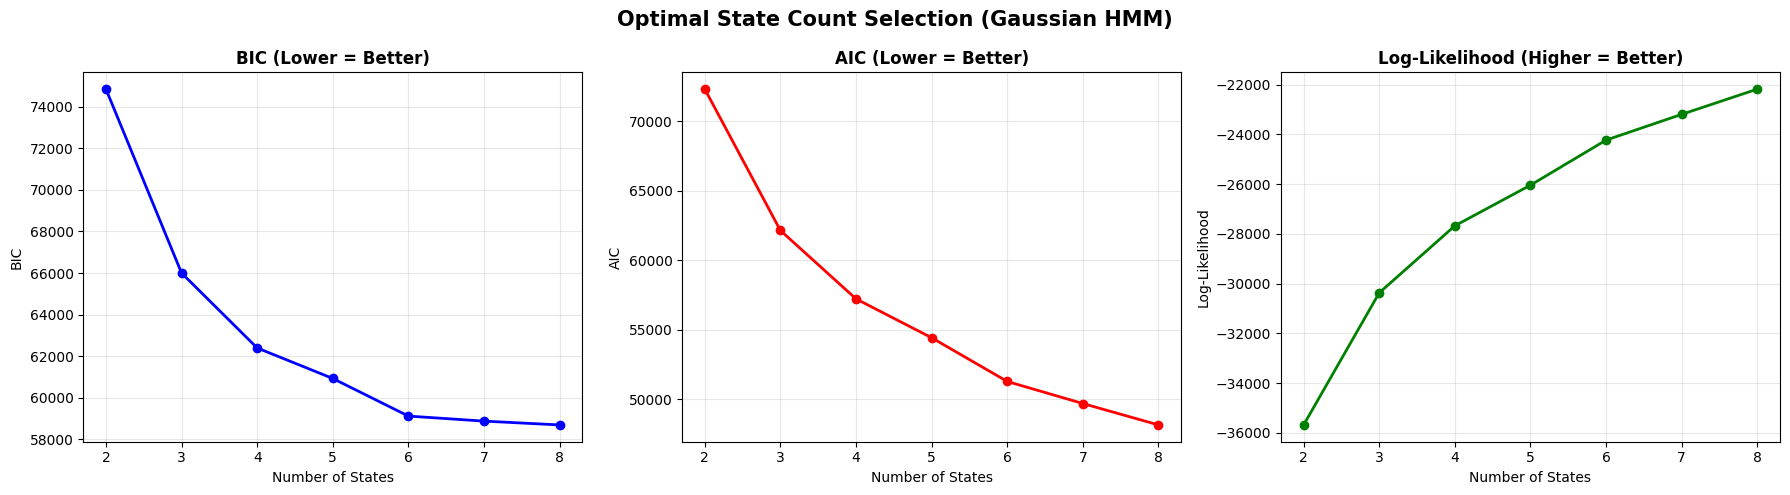


Best n_states by BIC: 8
Best n_states by AIC: 8


In [2]:
# Prepare per-country sequence lengths for HMM fitting.
# Data is already ordered country -> date so each sequence is contiguous.
countries = sorted(df_cluster['country'].unique())
lengths = [len(group) for _, group in df_cluster.groupby('country', sort=True)]

STATE_RANGE = range(2, 9)
N_INITS = 10  # random initializations per state count

bic_scores, aic_scores, log_likelihoods = [], [], []

for n_states in STATE_RANGE:
    best_ll = -np.inf
    best_model = None
    for init in range(N_INITS):
        model = GaussianHMM(
            n_components=n_states, covariance_type='full',
            n_iter=200, random_state=init, verbose=False,
        )
        model.fit(X_scaled, lengths)
        ll = model.score(X_scaled, lengths)
        if ll > best_ll:
            best_ll = ll
            best_model = model

    # Free-parameter count for full-covariance Gaussian HMM.
    n_features = X_scaled.shape[1]
    n_params = (
        n_states * (n_states - 1)  # transition matrix (row-stochastic)
        + (n_states - 1)           # initial state distribution
        + n_states * n_features     # means
        + n_states * n_features * (n_features + 1) // 2  # covariance
    )
    n_obs = X_scaled.shape[0]
    bic = -2 * best_ll + n_params * np.log(n_obs)
    aic = -2 * best_ll + 2 * n_params

    bic_scores.append(bic)
    aic_scores.append(aic)
    log_likelihoods.append(best_ll)
    print(f"  n_states={n_states}: BIC={bic:.1f}, AIC={aic:.1f}, LL={best_ll:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(STATE_RANGE), bic_scores, 'bo-', linewidth=2)
axes[0].set_title('BIC (Lower = Better)', fontweight='bold')
axes[0].set_xlabel('Number of States')
axes[0].set_ylabel('BIC')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(STATE_RANGE), aic_scores, 'ro-', linewidth=2)
axes[1].set_title('AIC (Lower = Better)', fontweight='bold')
axes[1].set_xlabel('Number of States')
axes[1].set_ylabel('AIC')
axes[1].grid(True, alpha=0.3)

axes[2].plot(list(STATE_RANGE), log_likelihoods, 'go-', linewidth=2)
axes[2].set_title('Log-Likelihood (Higher = Better)', fontweight='bold')
axes[2].set_xlabel('Number of States')
axes[2].set_ylabel('Log-Likelihood')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Optimal State Count Selection (Gaussian HMM)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

best_n_bic = list(STATE_RANGE)[np.argmin(bic_scores)]
best_n_aic = list(STATE_RANGE)[np.argmin(aic_scores)]
print(f"\nBest n_states by BIC: {best_n_bic}")
print(f"Best n_states by AIC: {best_n_aic}")

### Interpretation

Both BIC and AIC select **8 states within the tested range (2–8)**, and both curves decrease monotonically over that range. This supports using a relatively granular state space compared with K-Means, but it should be interpreted as **best among tested values**, not definitive proof that the global optimum is exactly 8.

A practical takeaway is that temporal structure appears informative enough to justify more than a small number of regimes, while still requiring caution about complexity, small-state sample sizes, and initialization sensitivity (evaluated later).

## Fit Final Gaussian HMM

With the optimal state count determined, we fit the final HMM with a full covariance matrix and best-of-N initializations. Each country-month observation is assigned to its most likely hidden state via the Viterbi algorithm (`predict`).

In [3]:
OPTIMAL_N = best_n_bic

# Best-of-N initializations for the final model
best_ll = -np.inf
best_hmm = None
for init in range(20):
    model = GaussianHMM(
        n_components=OPTIMAL_N, covariance_type='full',
        n_iter=200, random_state=init, verbose=False,
    )
    model.fit(X_scaled, lengths)
    ll = model.score(X_scaled, lengths)
    if ll > best_ll:
        best_ll = ll
        best_hmm = model

df_cluster['regime'] = best_hmm.predict(X_scaled, lengths)

print(f"Final log-likelihood: {best_ll:.1f}")
print_cluster_summary(X_scaled, df_cluster['regime'].values, OPTIMAL_N, 'Gaussian HMM')

Final log-likelihood: -21069.4
Gaussian HMM fitted with 8 clusters/states

Internal Validation Metrics:
  Silhouette Score:      0.0839
  Calinski-Harabasz:     194.8295
  Davies-Bouldin:        2.4903

Cluster Sizes:
  Regime 0:   238 observations (12.8%)
  Regime 1:   293 observations (15.8%)
  Regime 2:   162 observations (8.7%)
  Regime 3:   125 observations (6.7%)
  Regime 4:   130 observations (7.0%)
  Regime 5:   220 observations (11.9%)
  Regime 6:   406 observations (21.9%)
  Regime 7:   280 observations (15.1%)


### Interpretation

The final model converges with a log-likelihood of **-21,069.4** (best of 20 random initializations). The 8 regimes range from **6.7%** (Regime 3, 125 observations) to **21.9%** (Regime 6, 406 observations), with no empty states — each regime captures a meaningful subset of the data.

The silhouette score of **0.0839** is notably lower than typical K-Means results, which is expected and not a concern. HMMs optimize *sequential likelihood* (how well the state sequence explains the observed data over time) rather than *geometric compactness* (how close points are to their assigned centroid). Two observations in the same HMM state may be far apart in feature space if they share temporal context — e.g., both occur during transitions from expansion to contraction. The Calinski-Harabasz (194.82) and Davies-Bouldin (2.49) indices similarly reflect this fundamental difference in optimization objective.

The convergence warning for one initialization is benign — it indicates that particular random seed found a flat region of the likelihood surface, and the best-of-20 selection ensures the final model is not affected.

## Transition Probability Matrix

A key advantage of HMMs over K-Means is the learned **transition matrix**, which captures the probability of moving between regimes in consecutive time steps. High diagonal values indicate persistent ("sticky") regimes, while off-diagonal values reveal typical transition pathways.

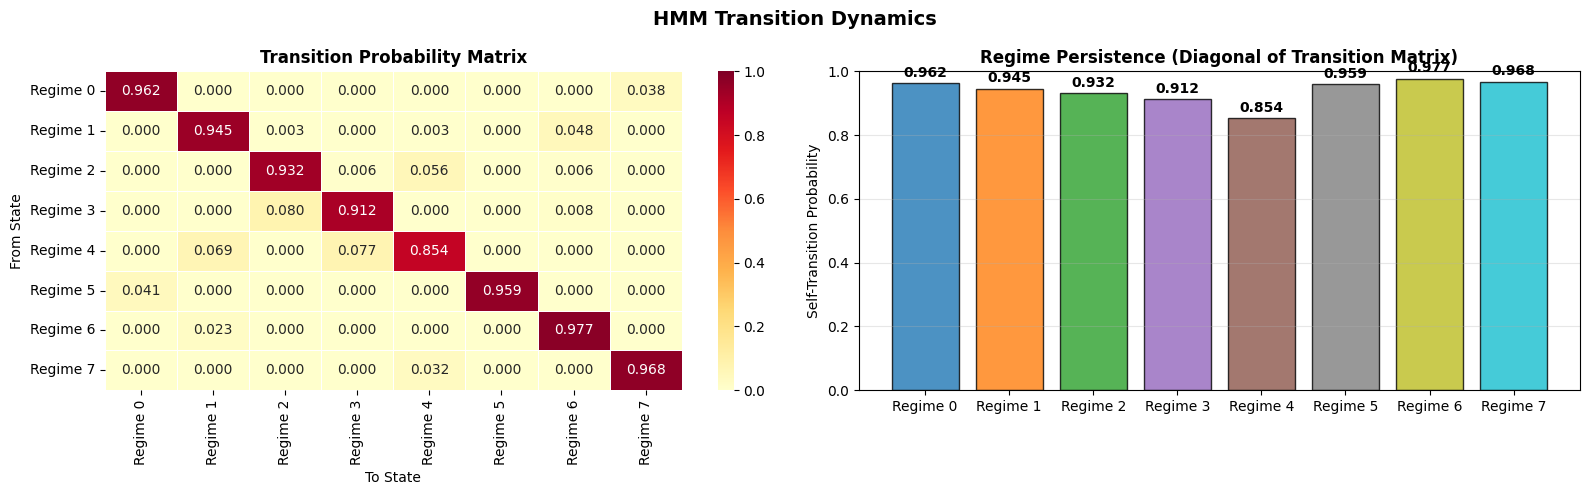

Transition Matrix:
  From Regime 0: [0.962 0.000 0.000 0.000 0.000 0.000 0.000 0.038]
  From Regime 1: [0.000 0.945 0.003 0.000 0.003 0.000 0.048 0.000]
  From Regime 2: [0.000 0.000 0.932 0.006 0.056 0.000 0.006 0.000]
  From Regime 3: [0.000 0.000 0.080 0.912 0.000 0.000 0.008 0.000]
  From Regime 4: [0.000 0.069 0.000 0.077 0.854 0.000 0.000 0.000]
  From Regime 5: [0.041 0.000 0.000 0.000 0.000 0.959 0.000 0.000]
  From Regime 6: [0.000 0.023 0.000 0.000 0.000 0.000 0.977 0.000]
  From Regime 7: [0.000 0.000 0.000 0.000 0.032 0.000 0.000 0.968]


In [4]:
transmat = best_hmm.transmat_

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full transition matrix heatmap
regime_labels = [f'Regime {i}' for i in range(OPTIMAL_N)]
sns.heatmap(transmat, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=regime_labels, yticklabels=regime_labels,
            linewidths=0.5, ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Transition Probability Matrix', fontweight='bold', fontsize=12)
axes[0].set_xlabel('To State')
axes[0].set_ylabel('From State')

# Self-transition (persistence) probabilities
self_trans = np.diag(transmat)
colors = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_N))
axes[1].bar(range(OPTIMAL_N), self_trans, color=colors[:OPTIMAL_N],
            edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(OPTIMAL_N))
axes[1].set_xticklabels(regime_labels)
axes[1].set_ylabel('Self-Transition Probability')
axes[1].set_title('Regime Persistence (Diagonal of Transition Matrix)',
                  fontweight='bold', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(self_trans):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('HMM Transition Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Transition Matrix:")
for i in range(OPTIMAL_N):
    row = ' '.join(f'{transmat[i, j]:.3f}' for j in range(OPTIMAL_N))
    print(f"  From Regime {i}: [{row}]")

### Interpretation

All 8 regimes are highly persistent, with self-transition probabilities ranging from **0.854** (Regime 4) to **0.977** (Regime 6). Once entered, any regime tends to last many consecutive months.

Off-diagonal transitions are **sparse** — each regime typically exits to only 1–3 other regimes — forming identifiable transition pathways:

- **Regimes 1 and 6** form a tightly coupled pair with reciprocal transitions (1 → 6, 6 → 1), and together dominate the long-run dynamics.
- **Regimes 2, 3, and 4** form a cyclical loop (2 → 4, 4 → 3, 3 → 2), with **Regime 4** as the least persistent and most transitional state.
- **Regimes 5, 0, and 7** form a one-way chain (5 → 0 → 7 → 4) that funnels into the cyclical core via Regime 4.
- Regime 4 also connects to Regime 1, bridging the cyclical loop to the dominant 1–6 pair.

This sparse, pathway-driven structure is consistent with sequential economic dynamics where regime shifts follow specific routes rather than random switching.

Despite uniformly high self-transition probabilities, **persistence does not determine long-run dominance**. A regime can be very sticky once entered yet still have low equilibrium frequency if inbound transitions from other regimes are scarce — for example, Regime 5 has no inbound transitions at all, so it eventually empties out despite a self-transition of 0.959. The stationary-distribution analysis in the next section disentangles persistence from long-run occupancy.

## Stationary Distribution & Expected Durations

The **stationary distribution** is the long-run fraction of time spent in each regime (left eigenvector of the transition matrix with eigenvalue 1). The **expected duration** of each regime is $1 / (1 - p_{ii})$ months, where $p_{ii}$ is the self-transition probability. Together these describe the equilibrium regime structure.

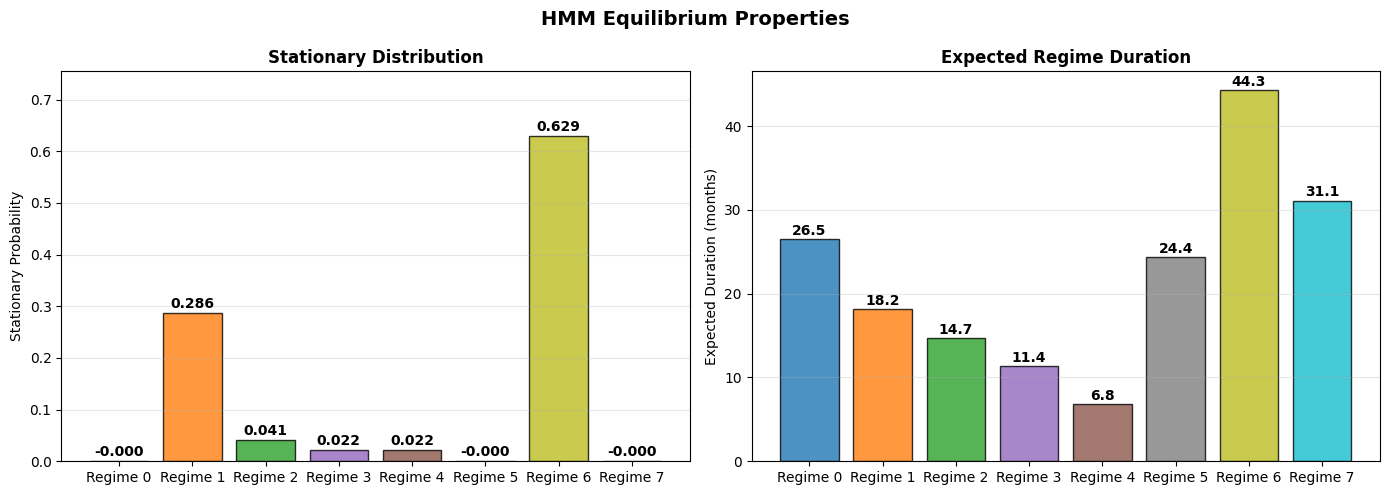

Stationary Distribution & Expected Durations:
  Regime 0: stationary prob = -0.000, expected duration = 26.5 months
  Regime 1: stationary prob = 0.286, expected duration = 18.2 months
  Regime 2: stationary prob = 0.041, expected duration = 14.7 months
  Regime 3: stationary prob = 0.022, expected duration = 11.4 months
  Regime 4: stationary prob = 0.022, expected duration = 6.8 months
  Regime 5: stationary prob = -0.000, expected duration = 24.4 months
  Regime 6: stationary prob = 0.629, expected duration = 44.3 months
  Regime 7: stationary prob = -0.000, expected duration = 31.1 months


In [5]:
# Stationary distribution: left eigenvector of transition matrix
eigenvalues, eigenvectors = np.linalg.eig(transmat.T)
# Find eigenvector corresponding to eigenvalue ~= 1
idx = np.argmin(np.abs(eigenvalues - 1.0))
stationary = np.real(eigenvectors[:, idx])
stationary = stationary / stationary.sum()  # normalize to probability

# Expected duration in each state (geometric distribution)
expected_duration = 1.0 / (1.0 - np.diag(transmat))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

regime_labels = [f'Regime {i}' for i in range(OPTIMAL_N)]
colors = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_N))

# Stationary distribution
axes[0].bar(range(OPTIMAL_N), stationary, color=colors[:OPTIMAL_N],
            edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(OPTIMAL_N))
axes[0].set_xticklabels(regime_labels)
axes[0].set_ylabel('Stationary Probability')
axes[0].set_title('Stationary Distribution', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, max(stationary) * 1.2)
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(stationary):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Expected duration
axes[1].bar(range(OPTIMAL_N), expected_duration, color=colors[:OPTIMAL_N],
            edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(OPTIMAL_N))
axes[1].set_xticklabels(regime_labels)
axes[1].set_ylabel('Expected Duration (months)')
axes[1].set_title('Expected Regime Duration', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(expected_duration):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('HMM Equilibrium Properties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Stationary Distribution & Expected Durations:")
for i in range(OPTIMAL_N):
    print(f"  Regime {i}: stationary prob = {stationary[i]:.3f}, "
          f"expected duration = {expected_duration[i]:.1f} months")

### Interpretation

The stationary distribution is heavily concentrated in **Regime 6** (0.629) and **Regime 1** (0.286), which together account for over 90% of long-run occupancy. This reflects their reciprocal transition link — they continually feed probability mass to each other — combined with high persistence once entered.

Regimes 0, 5, and 7 have near-zero stationary probability despite high self-transition rates (0.959–0.968). They form a one-way chain (5 → 0 → 7 → 4) with no return flow, making them effectively **transient** states the system passes through but does not revisit in equilibrium. Regimes 2, 3, and 4 retain small but non-zero stationary mass through their cyclical loop.

Expected durations should be read against the **~206-month observation window** per country (2001-11 to 2018-12). Regime 6's expected duration of 44.3 months (~3.7 years per episode) combines with high inbound flow to produce long-run dominance. Regime 4, by contrast, lasts only 6.8 months on average — consistent with its role as a transitional hub. Regimes 0 and 7 have long expected durations (26.5 and 31.1 months) but near-zero stationary mass — they are sticky once entered but rarely reached.

## Cluster Profiling (Regime Characterization)

HMM state means (`model.means_`) play a role analogous to K-Means cluster centers. The first heatmap shows means in original units for direct interpretation; the second shows standardized values highlighting each regime's deviation from the dataset mean.

### Interpretation Framework

This section profiles regime centroids (`means_`) and feature distributions to assign economically interpretable labels to each state. Interpretation appears after the profiling outputs below.

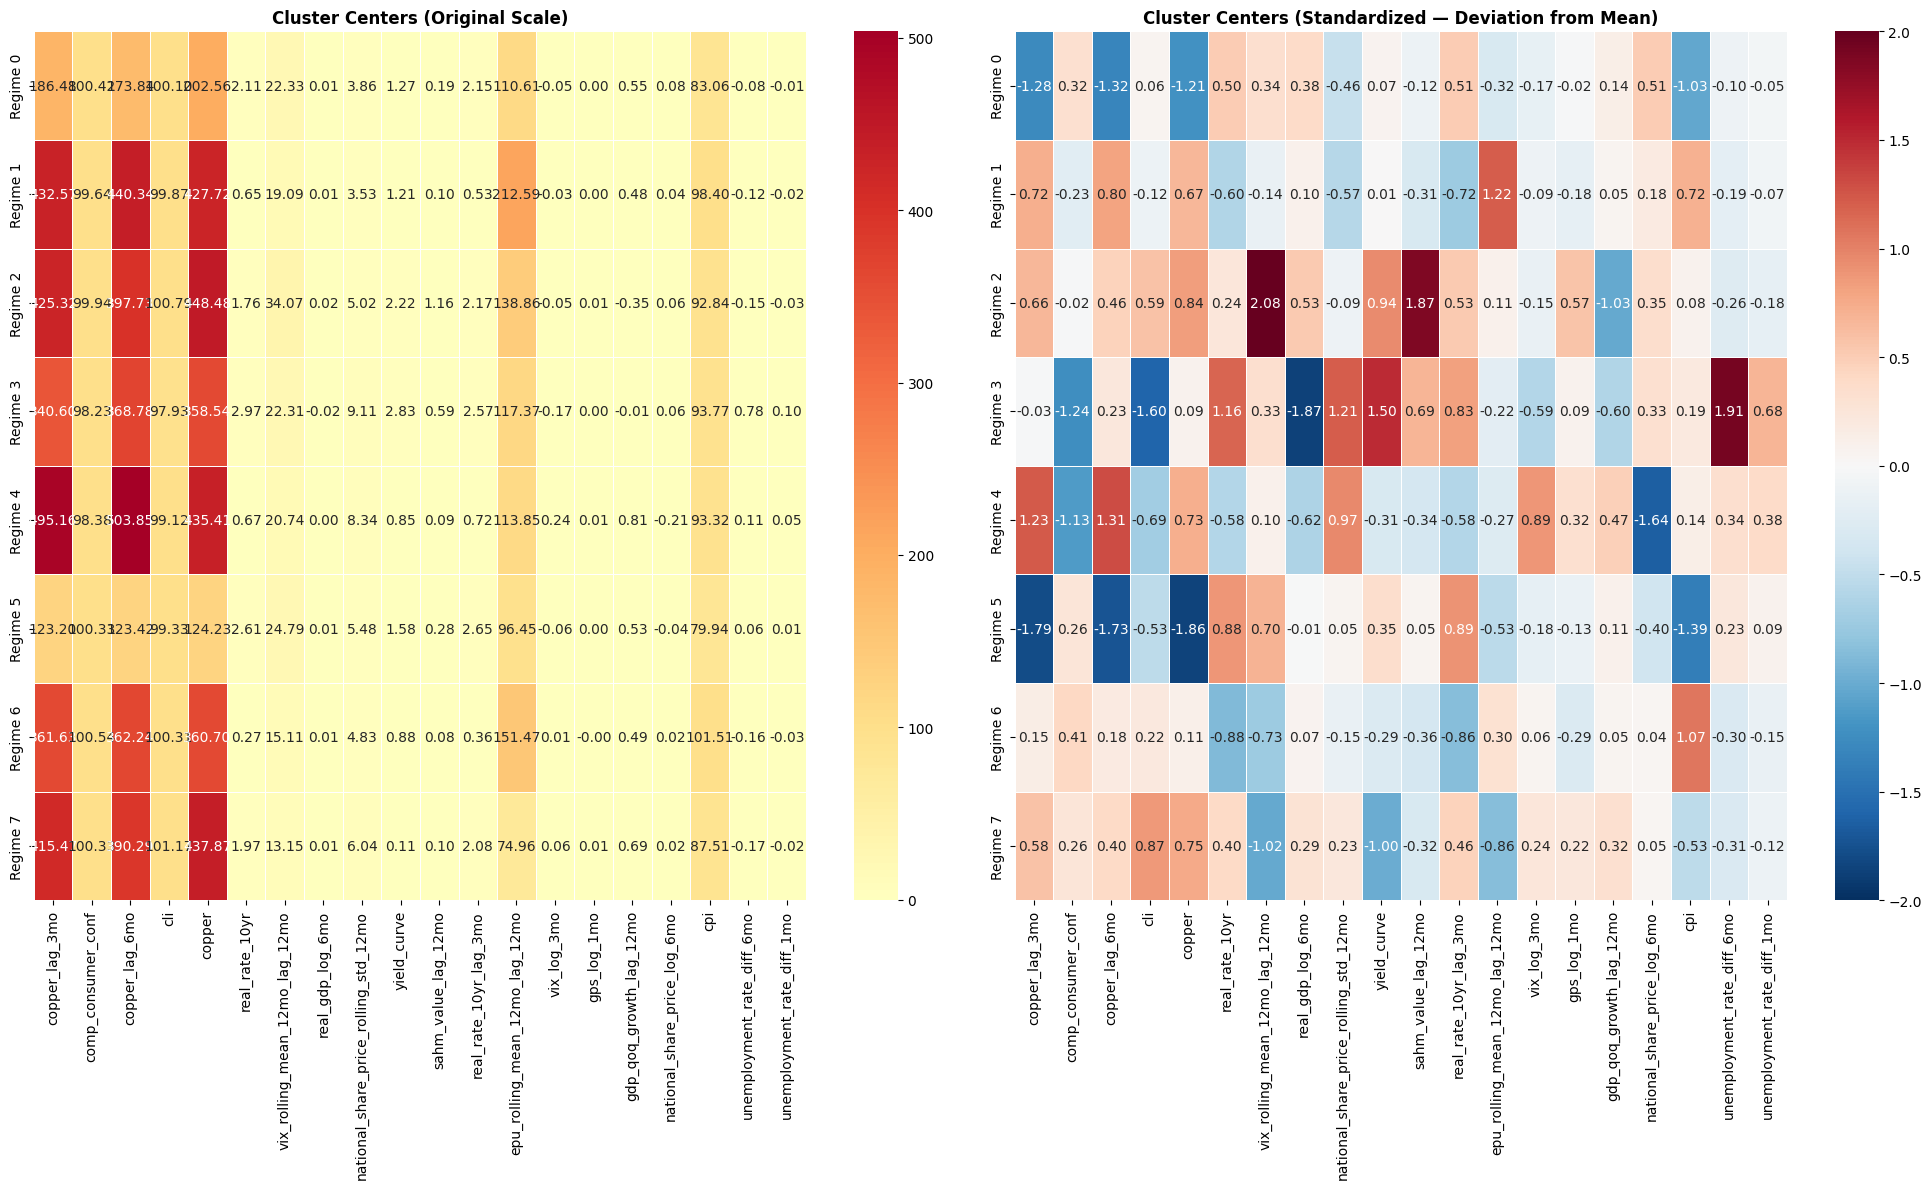

Regime Profiles (Original Scale):
                                         Regime 0    Regime 1    Regime 2    Regime 3    Regime 4    Regime 5    Regime 6    Regime 7
copper_lag_3mo                         186.481836  432.568919  425.322609  340.602797  495.160388  123.200491  361.630886  415.473204
comp_consumer_conf                     100.416966   99.639973   99.939319   98.232017   98.382803  100.328592  100.536413  100.325847
copper_lag_6mo                         173.836552  440.342519  397.727323  368.784828  503.847742  123.421592  362.243111  390.294652
cli                                    100.103765   99.866565  100.793696   97.929259   99.123804   99.329439  100.310826  101.170073
copper                                 202.560089  427.723949  448.482166  358.541856  435.411532  124.234235  360.698215  437.873928
real_rate_10yr                           2.106913    0.647843    1.761521    2.972707    0.671747    2.605065    0.274324    1.967939
vix_rolling_mean_12mo_lag_12

In [6]:
centers_original = scaler.inverse_transform(best_hmm.means_)
plot_center_heatmaps(centers_original, best_hmm.means_, CLUSTER_FEATURES, OPTIMAL_N)

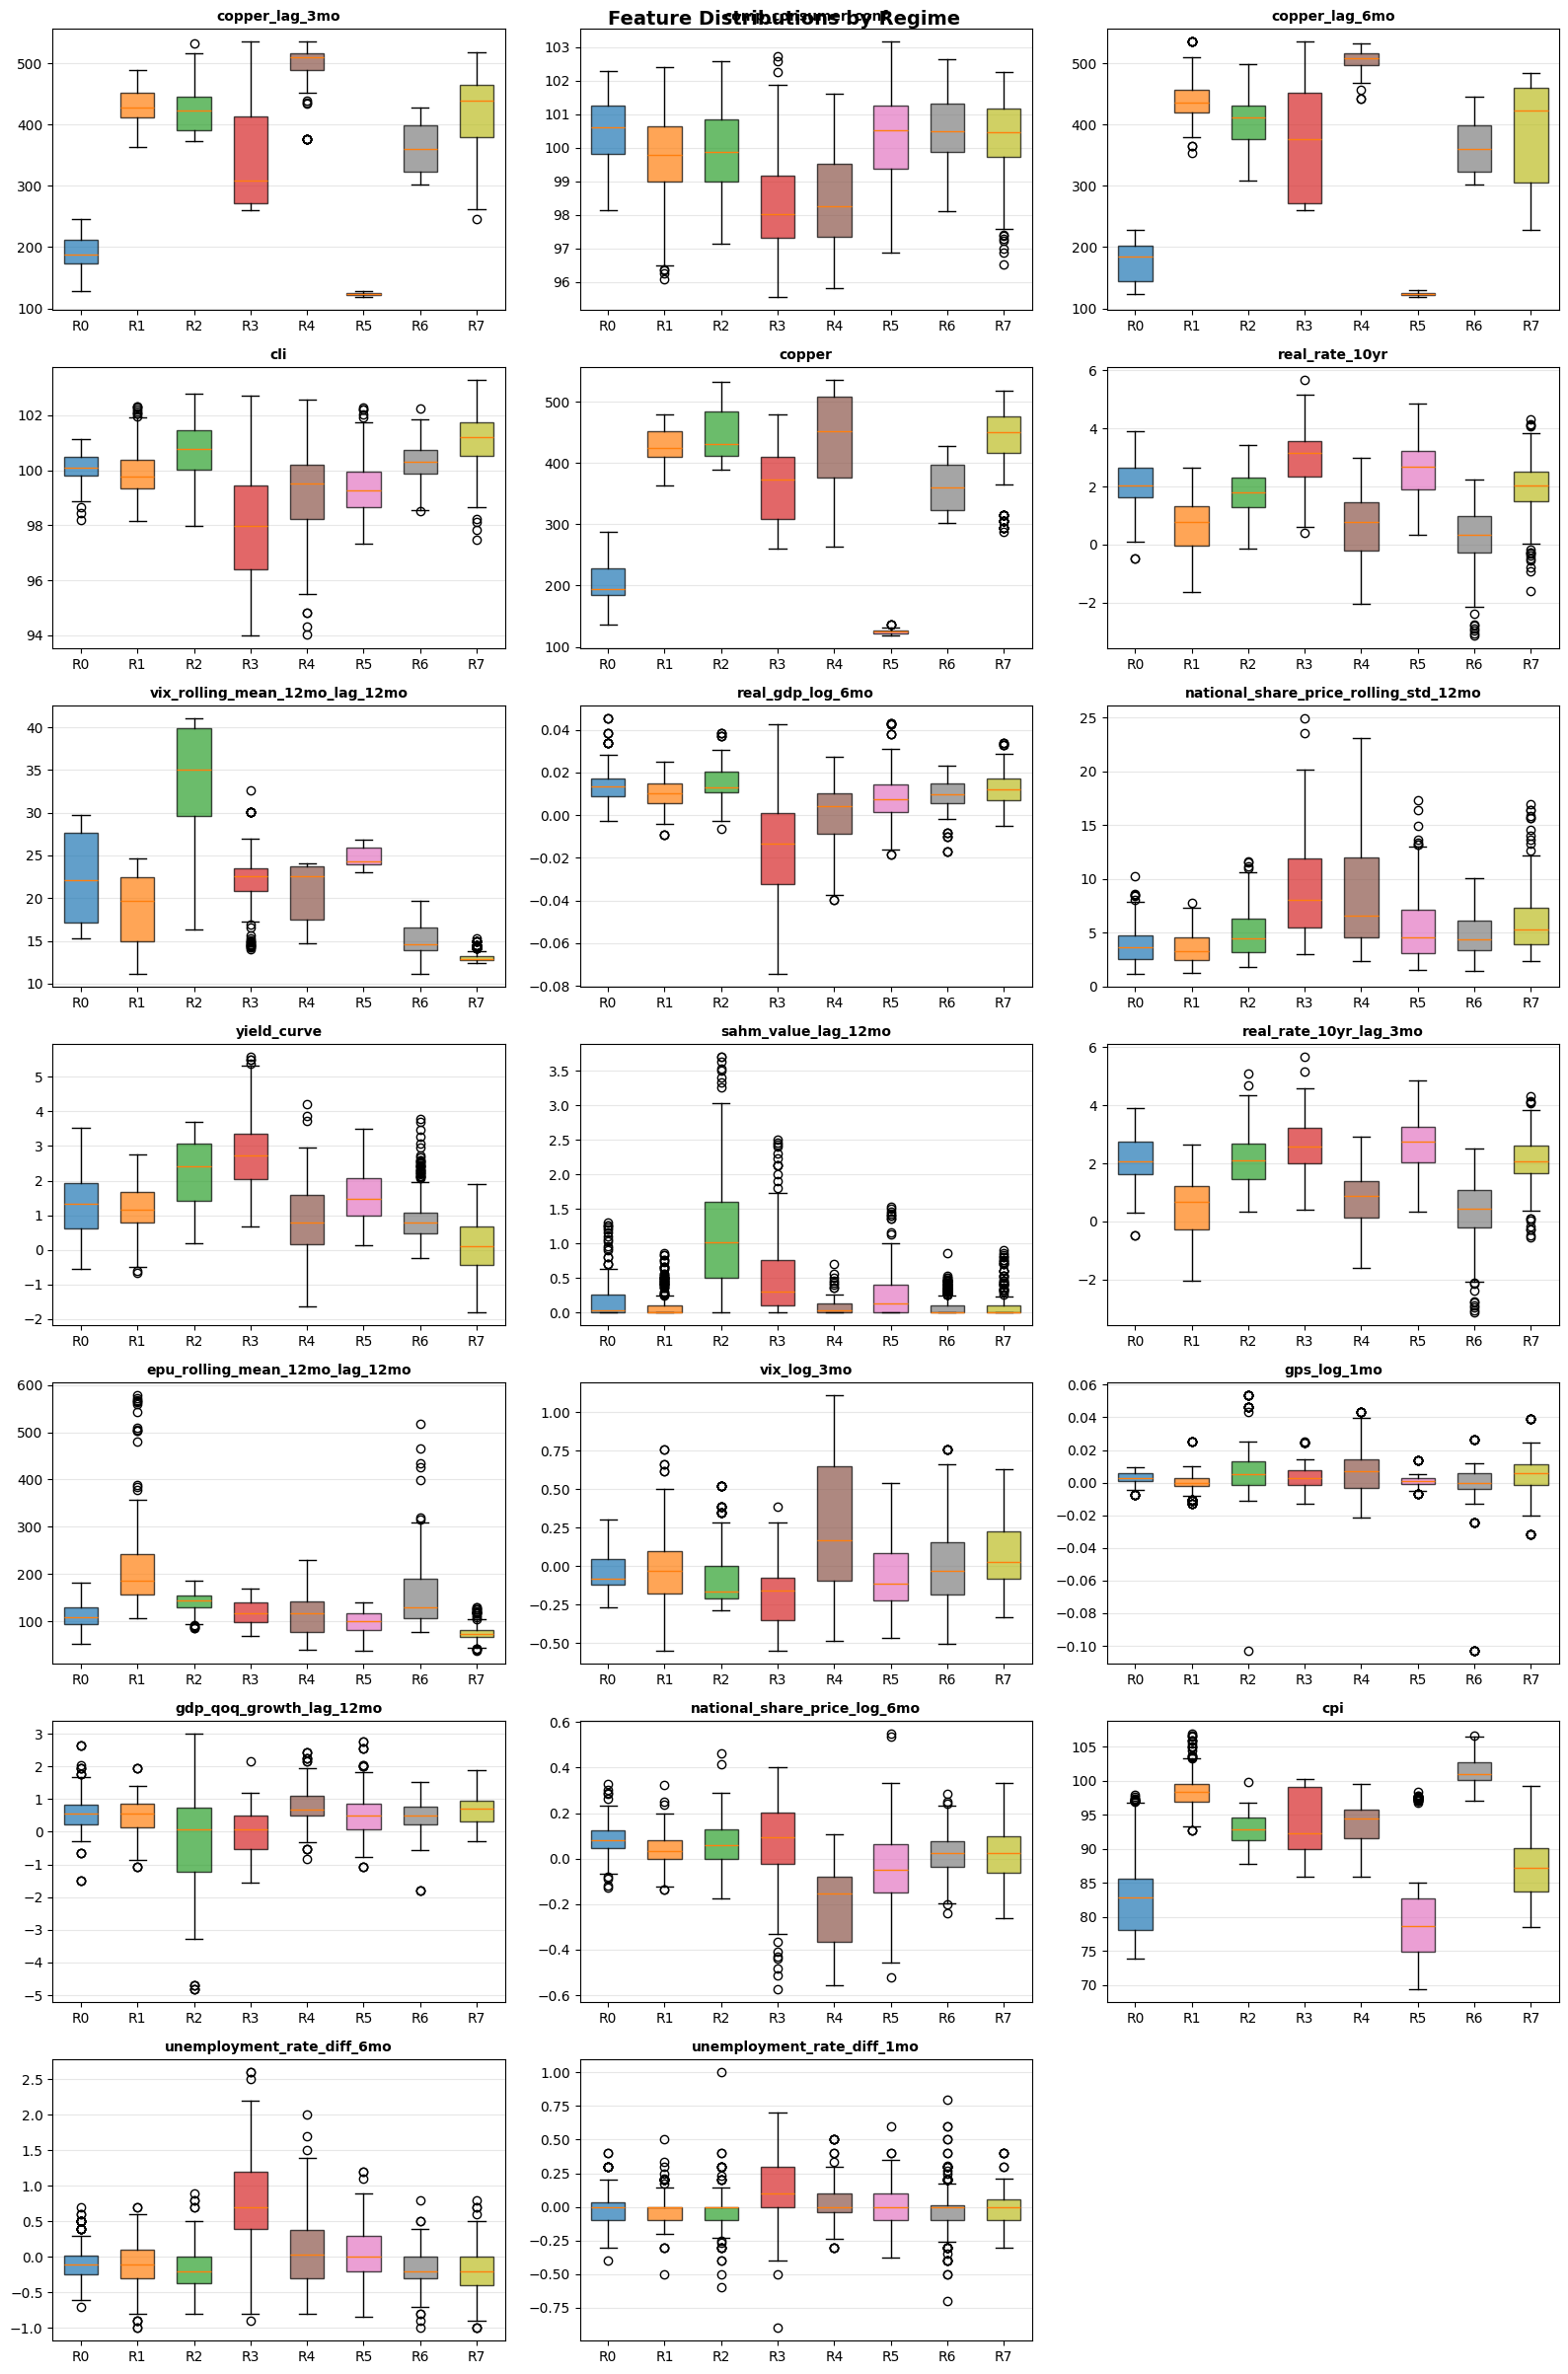

In [7]:
plot_feature_boxplots(df_cluster, CLUSTER_FEATURES, OPTIMAL_N)

### Regime Characterization

Examining the state means and feature distributions, we can assign economic interpretations to each regime:

| Regime | Size | Label | Key Indicators |
|--------|------|-------|----------------|
| **0** | 12.8% | **Early-2000s Stable** | Low copper (~203), moderate-high real rates (~2.1%), positive yield curve (~1.3%), low equity volatility (~3.9%), low CPI (~83). Early-period conditions with low commodity prices and conventional monetary policy. |
| **1** | 15.8% | **Policy Uncertainty** | High copper (~428), highest EPU (~213), low real rates (~0.6%), moderate growth, improving unemployment. High commodity prices combined with elevated policy uncertainty — consistent with periods of contentious fiscal or monetary policy debates. |
| **2** | 8.7% | **Post-Crisis Recovery** | Highest SAHM lag (~1.16, lingering unemployment), highest VIX lag (~34, volatility memory), steep yield curve (~2.2, accommodative policy), negative lagged GDP QoQ (-0.35). Recessions have technically ended but labor markets remain stressed. |
| **3** | 6.7% | **Recessionary Stress** | Negative GDP growth (-0.015), highest real rates (~3.0%), steepest yield curve (~2.8, aggressive easing), highest unemployment acceleration (+0.78 over 6 months), high equity volatility (~9.1). Active contraction with aggressive monetary policy response. |
| **4** | 7.0% | **Short Transitional** | Near-zero GDP growth (~0.001), declining copper from peak levels (lag_6mo ~504), highest rising VIX (+0.24 over 3 months), sharpest equity declines (-0.21 over 6 months). Expected duration of only 6.8 months — a brief bridge between regimes rather than a sustained economic state. |
| **5** | 11.9% | **Pre-Commodity-Boom** | Lowest copper (~124), high real rates (~2.6%), lowest CPI (~80), moderate VIX lag (~25), low EPU (~96). Early-period conditions before the global commodity supercycle, with higher conventional interest rates. |
| **6** | 21.9% | **Low-Rate Expansion** | Lowest real rates (~0.27%), highest CPI (~102), low VIX lag (~15), moderate growth. Post-crisis accommodative monetary environment — the dominant long-run regime with 44.3-month expected duration and 0.629 stationary probability. |
| **7** | 15.1% | **Mature Expansion** | Highest CLI (~101), lowest VIX lag (~13), lowest EPU (~75), positive GDP growth (~0.012), near-flat yield curve (~0.1). Broad-based expansion with high confidence and low uncertainty, though the flat curve may signal late-cycle dynamics. |

The heatmaps and boxplots above confirm these profiles. **Copper prices** are a strong differentiator across regimes, serving as a proxy for the global commodity cycle (Regimes 5 and 0 at the low end, Regimes 1 and 4 at the high end). **VIX lag**, **yield curve**, **real rates**, and **SAHM lag** capture financial conditions, monetary policy stance, and labor market health respectively.

### Interpretation

The center heatmaps and per-feature boxplots support the regime labels in the characterization table: a small set of indicators — notably copper (and its lags), VIX-related measures, yield curve, real rates, and SAHM lag — provides most of the separation between states.

Regimes with strong centroid separation (e.g., Regime 3's negative growth and steep curve, Regime 5's very low copper) are the most profile-driven. Transitional regimes like Regime 4 show more overlap in feature distributions and are better distinguished by their transition dynamics (short duration, specific entry/exit pathways) than by geometry alone.

## Temporal Analysis

How do HMM-discovered regimes evolve over time? The stacked area chart shows what fraction of countries occupy each regime at every date. The heatmap shows regime assignments per country, revealing synchronized vs. idiosyncratic transitions.

### Temporal Analysis Plan

We first visualize aggregate regime composition over time, then country-level timelines/proportions. Interpretation follows after both temporal plots.

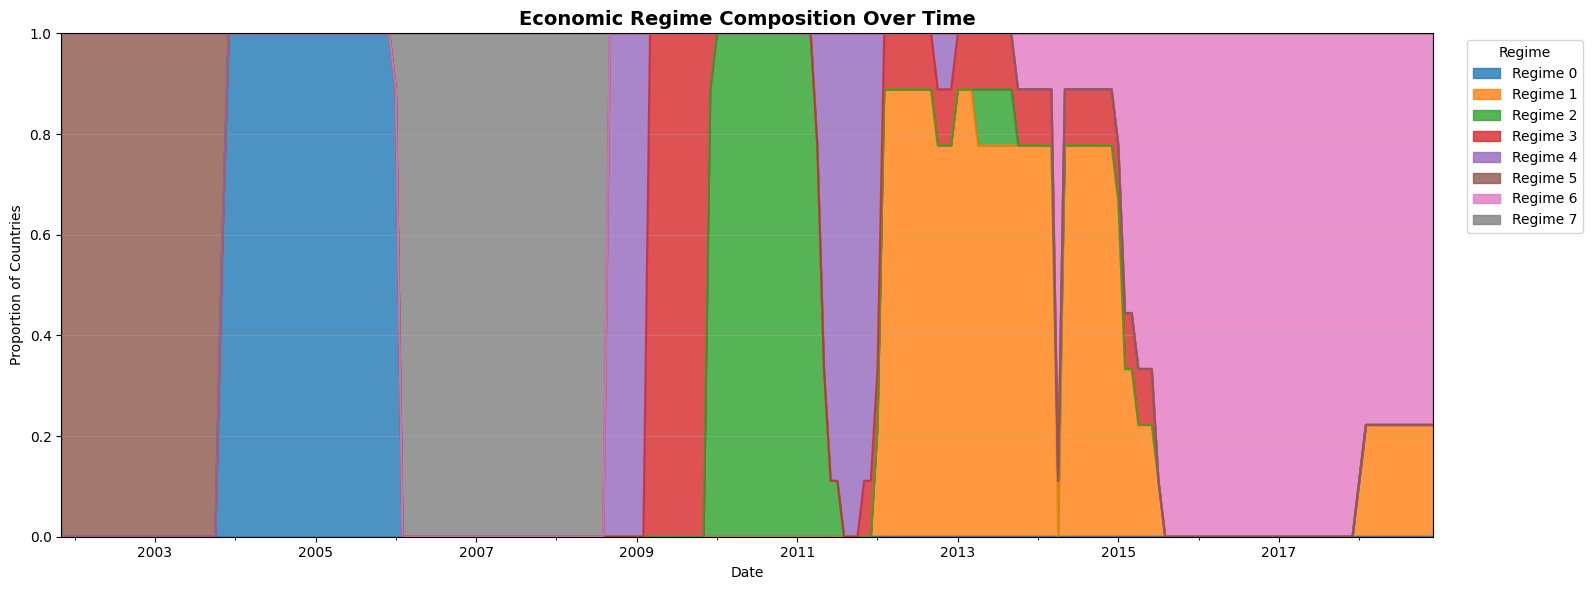

In [8]:
plot_regime_composition_over_time(df_cluster, OPTIMAL_N)

### Country-Level Temporal View

The next plot extends the temporal analysis from aggregate composition to country-specific regime paths and long-run shares.

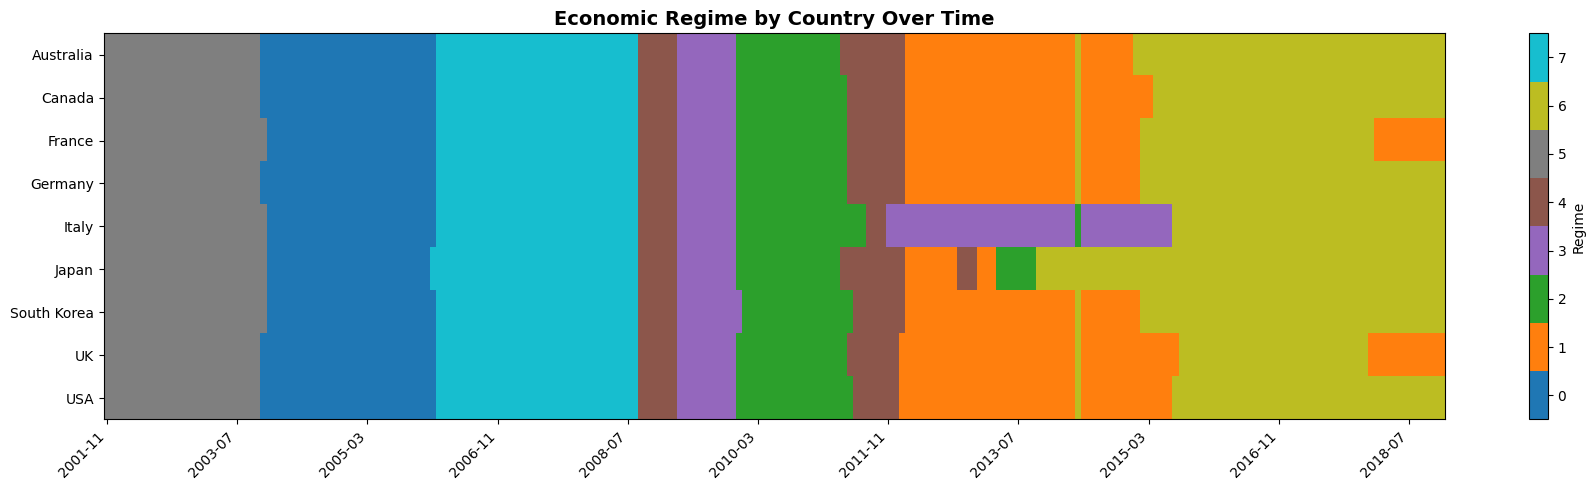

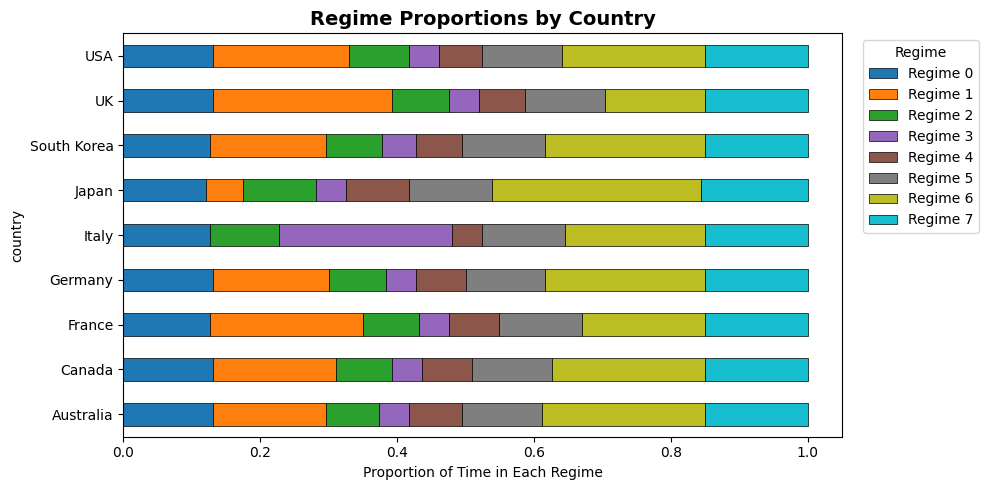

In [9]:
plot_country_regime_analysis(df_cluster, OPTIMAL_N)

### Interpretation

The temporal evolution maps to recognizable macro episodes:

- **Early 2000s**: Regimes 0 and 5 (low-copper, higher-rate profiles) are more prevalent, consistent with pre-commodity-boom conditions.
- **2007–2009 (GFC)**: A visible shift toward stress and transitional regimes (notably 3 and 4) appears across many countries, reflecting the global financial crisis.
- **Post-GFC period**: Regimes 2 (post-crisis recovery) and 6 (low-rate expansion) become more common, consistent with accommodative monetary policy and gradual labor market healing.

Country-level heatmaps show both synchronization and idiosyncrasy: global shocks induce shared switching episodes, while structural differences still produce distinct country paths.

## PCA & t-SNE Visualization

Two complementary projections of the feature space to 2D, now colored by HMM state assignments:
- **PCA** (linear): Preserves global variance structure. HMM state means are projected as centroids.
- **t-SNE** (non-linear): Preserves local neighborhood structure, revealing cluster shapes.

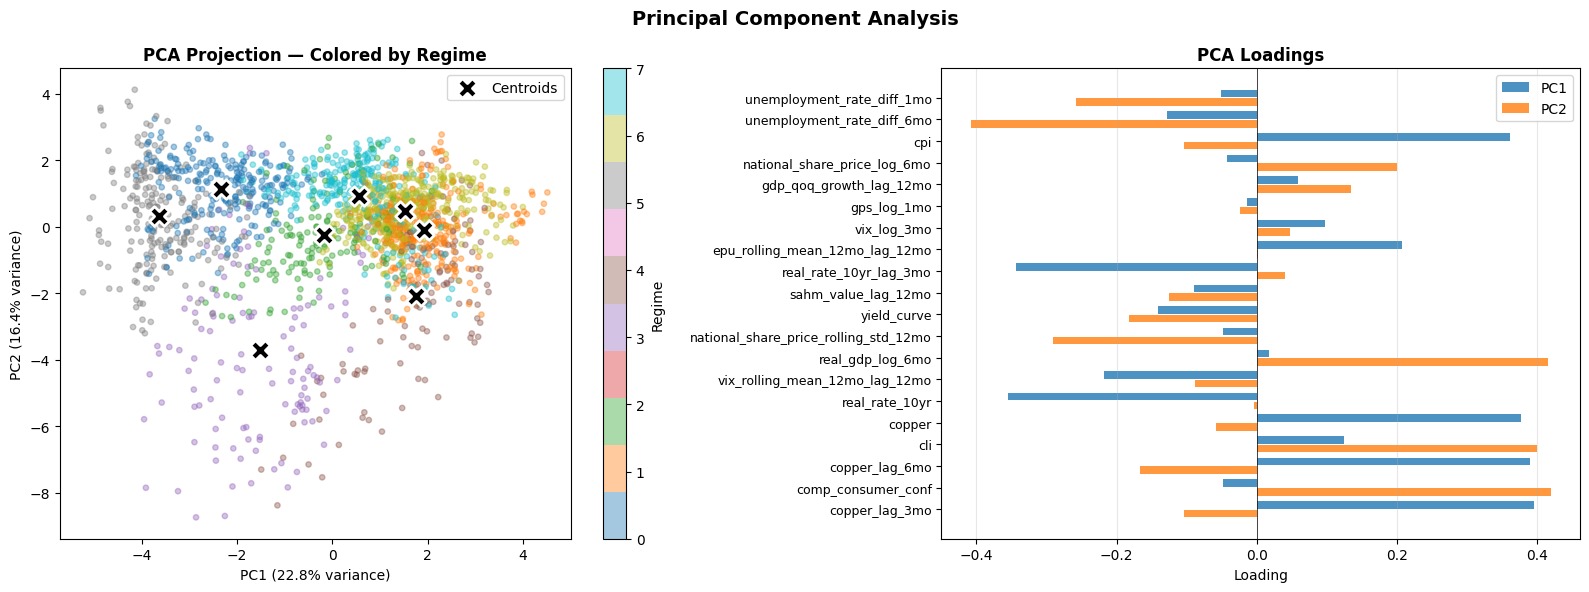

Explained variance: PC1=22.8%, PC2=16.4%, Total=39.2%


In [10]:
X_pca, pca, centers_pca = plot_pca_analysis(
    X_scaled, df_cluster['regime'].values, CLUSTER_FEATURES, OPTIMAL_N,
    centers_scaled=best_hmm.means_,
)

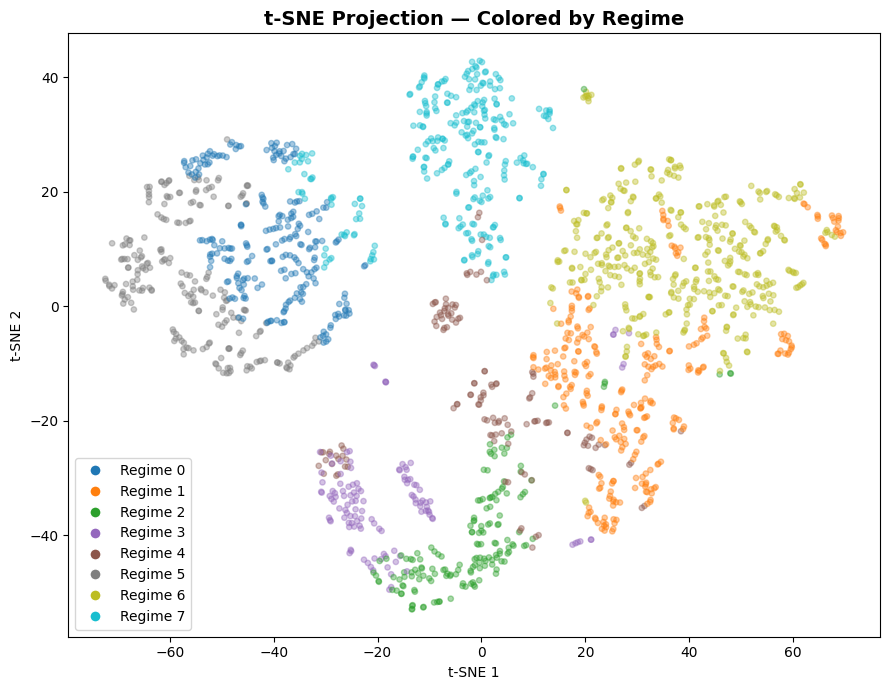

In [11]:
X_tsne = plot_tsne(X_scaled, df_cluster['regime'].values, OPTIMAL_N)

### Interpretation

With **39.2% of variance** explained by the first two principal components, PCA captures meaningful global structure but leaves substantial information in higher dimensions. The HMM boundaries in PCA space are expected to look less clean than K-Means because assignments are based on sequential likelihood, not nearest-centroid geometry.

The t-SNE view complements PCA by preserving local neighborhoods; use it for local cohesion patterns, not global distances. Together, the plots suggest the states have geometric signal while still requiring transition context for full separation.

## Post-hoc Recession Overlay

As a purely **interpretive** step, we compare the HMM-discovered regimes to known OECD recession periods. This examines whether the HMM naturally separates recessionary from non-recessionary conditions, without having used recession labels during fitting.

Post-hoc Recession Overlap Analysis
(Fraction of each regime's observations that fall during known OECD recessions)

  Regime 0:   35/238 during recession (14.7%)
  Regime 1:  169/293 during recession (57.7%)
  Regime 2:   28/162 during recession (17.3%)
  Regime 3:   54/125 during recession (43.2%)
  Regime 4:   88/130 during recession (67.7%)
  Regime 5:  130/220 during recession (59.1%)
  Regime 6:  117/406 during recession (28.8%)
  Regime 7:   71/280 during recession (25.4%)

  Overall recession rate in dataset: 37.3%


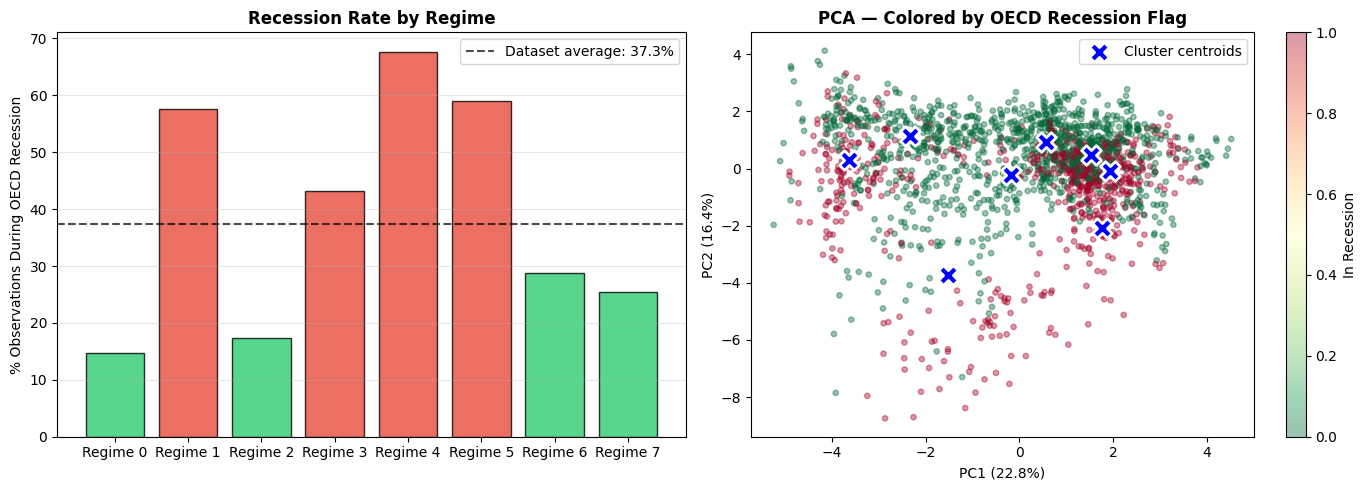

In [12]:
plot_recession_overlay(df_cluster, df_cluster['regime'].values, OPTIMAL_N,
                       X_pca, pca, centers_pca=centers_pca)

### Interpretation

The post-hoc recession overlay reveals a clear recession-association gradient across regimes (baseline recession rate ~37.3%):

- **Above baseline**: Regime 4 (67.7%), Regime 5 (59.1%), Regime 1 (57.7%), and Regime 3 (43.2%) all have recession shares well above the dataset average.
- **Below baseline**: Regime 6 (28.8%), Regime 7 (25.4%), Regime 2 (17.3%), and Regime 0 (14.7%) are predominantly non-recessionary.

Regime 4 (short transitional) has the highest recession overlap at 67.7%, consistent with its role as a brief bridge during deteriorating conditions. Regime 3 (recessionary stress) has a lower overlap than might be expected (43.2%) given its negative-growth profile — this likely reflects that some observations with recession-like indicators fall outside of OECD-defined recession windows, or that the HMM captures stress conditions that precede or follow formal recessionary periods.

This ordering supports a meaningful business-cycle hierarchy discovered without recession labels during HMM fitting.

## Cluster Stability Analysis

HMMs are more sensitive to initialization than K-Means due to EM's local convergence. We refit the model 50 times with different random seeds and measure agreement with the reference solution using the Adjusted Rand Index (ARI).

Model is not converging.  Current: -23706.901018767978 is not greater than -23451.383361415385. Delta is -255.51765735259323


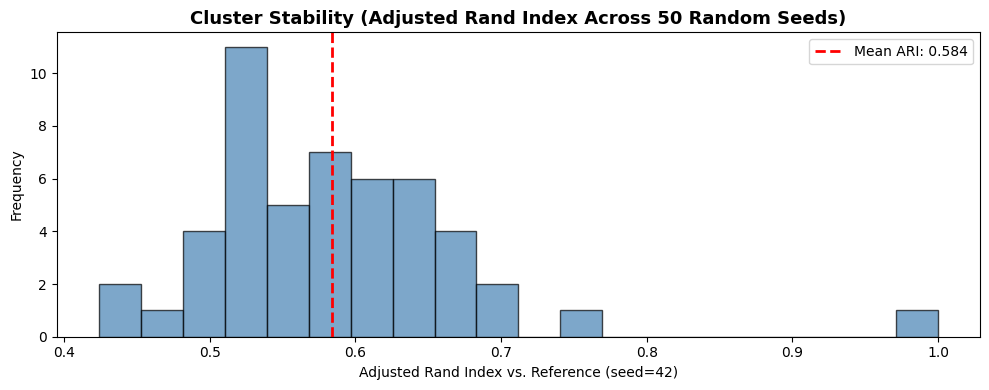

Stability Summary:
  Mean ARI: 0.5836
  Std ARI:  0.0908
  Min ARI:  0.4239
  Max ARI:  1.0000
  Clusters show instability — results are sensitive to initialization.


In [13]:
N_SEEDS = 50
reference_labels = df_cluster['regime'].values
ari_scores = []

for seed in range(N_SEEDS):
    hmm_temp = GaussianHMM(
        n_components=OPTIMAL_N, covariance_type='full',
        n_iter=200, random_state=seed, verbose=False,
    )
    hmm_temp.fit(X_scaled, lengths)
    temp_labels = hmm_temp.predict(X_scaled, lengths)
    ari_scores.append(adjusted_rand_score(reference_labels, temp_labels))

plot_stability_ari(ari_scores, 'Gaussian HMM', N_SEEDS)

### Interpretation

The stability analysis confirms that the 8-state HMM is **moderately sensitive to initialization**, with a mean ARI of **0.584** (std 0.091) across 50 refits. This is substantially lower than typical K-Means stability on the same data and reflects the well-known challenge of EM-based estimation in high-dimensional, multi-state HMMs — the likelihood surface has many local optima.

The wide ARI range (0.42–1.00) indicates that some initializations recover solutions nearly identical to the reference, while others converge to meaningfully different state partitions. This does not invalidate the analysis — the best-of-N initialization strategy used for the final model selects the highest-likelihood solution, which is the standard approach — but it does mean the specific regime boundaries should be interpreted with caution. The broad economic narratives (e.g., crisis vs. expansion vs. recovery) are likely robust across initializations even when fine-grained state assignments shift.